Loaded 10324 triples
modification_method: 366 unique entities
extraction_method: 141 unique entities
material_used_directly: 780 unique entities


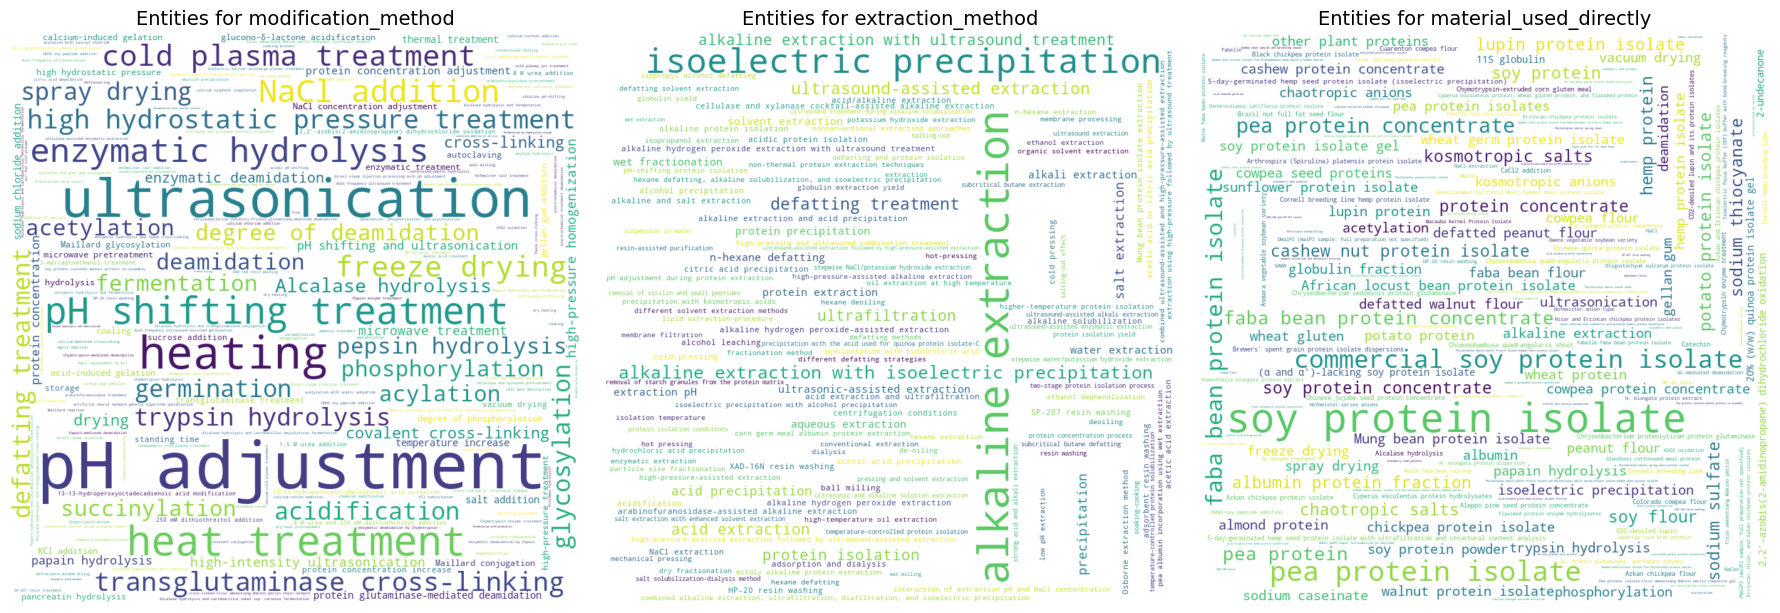


Saved word cloud image to wordclouds_method_material.png
Saved underlying frequency tables to wordcloud_frequencies.xlsx


In [3]:
"""
Word clouds for entities under three closed-taxonomy types:
modification_method, extraction_method, material_used_directly.

Sized by doi-adjusted document frequency (number of unique papers
mentioning each entity), not raw triple count, consistent with the
rest of this pipeline's frequency analysis, since raw counts can be
inflated by a small number of papers repeating the same entity many
times (chunking artifacts), which would distort word size unfairly.

Designed for Jupyter/Colab execution. No __main__ guard.
"""

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# ---------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------
TRIPLES_PATH = "type_resolved_triples_v2.xlsx"
SOURCE_COL = "resolved_source"
TARGET_COL = "resolved_target"
SOURCE_TYPE_COL = "source_type"
TARGET_TYPE_COL = "target_type"
DOI_COL = "doi"

TYPES_TO_PLOT = ["modification_method", "extraction_method", "material_used_directly"]

OUTPUT_PLOT = "wordclouds_method_material.png"
OUTPUT_XLSX = "wordcloud_frequencies.xlsx"

# ---------------------------------------------------------------
# LOAD
# ---------------------------------------------------------------
df = pd.read_excel(TRIPLES_PATH)
print(f"Loaded {len(df)} triples")

# ---------------------------------------------------------------
# BUILD DOI-ADJUSTED FREQUENCY PER TYPE
# an entity's frequency for a given TYPE is based only on the rows
# where it actually carries that type, e.g. if the same entity string
# somehow appeared under two different types (shouldn't happen post
# type-resolution, but this keeps it correct either way), each type
# gets its own independent count
# ---------------------------------------------------------------
source_long = pd.DataFrame({
    "entity": df[SOURCE_COL], "entity_type": df[SOURCE_TYPE_COL], DOI_COL: df[DOI_COL],
})
target_long = pd.DataFrame({
    "entity": df[TARGET_COL], "entity_type": df[TARGET_TYPE_COL], DOI_COL: df[DOI_COL],
})
entity_type_long = pd.concat([source_long, target_long])
entity_type_long["entity"] = entity_type_long["entity"].astype(str).str.strip()

type_frequencies = {}
freq_tables = {}

for t in TYPES_TO_PLOT:
    subset = entity_type_long[entity_type_long["entity_type"] == t]
    doc_freq = subset.groupby("entity")[DOI_COL].nunique()
    type_frequencies[t] = doc_freq.to_dict()
    freq_tables[t] = doc_freq.sort_values(ascending=False).reset_index()
    freq_tables[t].columns = ["entity", "doc_frequency"]
    print(f"{t}: {len(doc_freq)} unique entities")

# ---------------------------------------------------------------
# GENERATE WORD CLOUDS
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, len(TYPES_TO_PLOT), figsize=(6 * len(TYPES_TO_PLOT), 6))
if len(TYPES_TO_PLOT) == 1:
    axes = [axes]

for ax, t in zip(axes, TYPES_TO_PLOT):
    freqs = type_frequencies[t]
    if not freqs:
        ax.text(0.5, 0.5, "No entities found", ha="center", va="center")
        ax.axis("off")
        continue
    wc = WordCloud(
        width=800, height=800, background_color="white",
        colormap="viridis", prefer_horizontal=0.9,
    ).generate_from_frequencies(freqs)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"Entities for {t}", fontsize=14)
    ax.axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_PLOT, dpi=600, bbox_inches="tight")
plt.show()
print(f"\nSaved word cloud image to {OUTPUT_PLOT}")

# ---------------------------------------------------------------
# SAVE UNDERLYING FREQUENCY TABLES
# ---------------------------------------------------------------
with pd.ExcelWriter(OUTPUT_XLSX) as writer:
    for t in TYPES_TO_PLOT:
        freq_tables[t].to_excel(writer, sheet_name=t[:31], index=False)  # Excel sheet name limit

print(f"Saved underlying frequency tables to {OUTPUT_XLSX}")

In [5]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


#Top 20

Loaded 10324 triples
modification_method: 366 unique entities total, showing top 50
extraction_method: 141 unique entities total, showing top 50
material_used_directly: 780 unique entities total, showing top 50


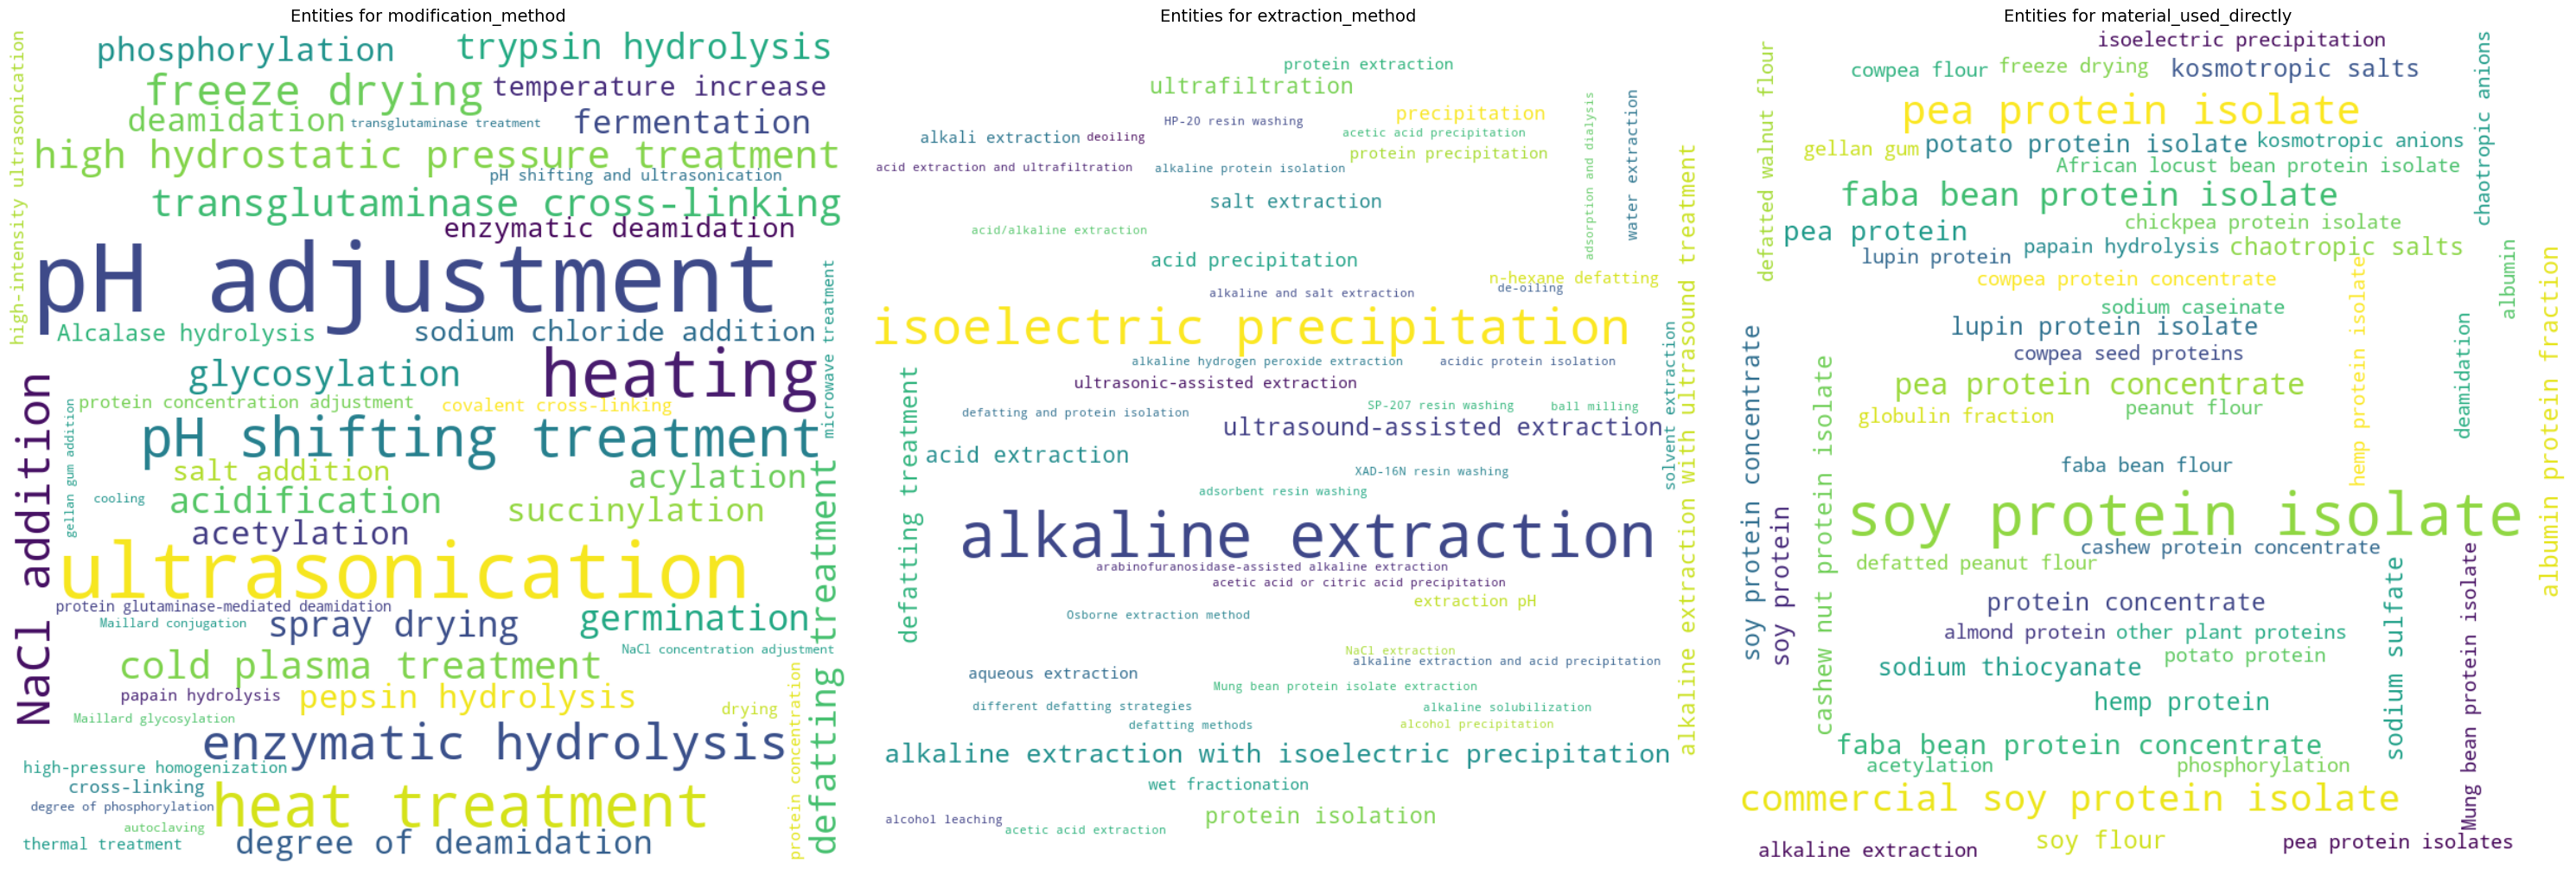


Saved word cloud image to wordclouds_method_material.png
Saved underlying frequency tables to wordcloud_frequencies.xlsx


In [5]:
"""
Word clouds for entities under three closed-taxonomy types:
modification_method, extraction_method, material_used_directly.

Sized by doi-adjusted document frequency (number of unique papers
mentioning each entity), not raw triple count, consistent with the
rest of this pipeline's frequency analysis, since raw counts can be
inflated by a small number of papers repeating the same entity many
times (chunking artifacts), which would distort word size unfairly.

Designed for Jupyter/Colab execution. No __main__ guard.
"""

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# ---------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------
TRIPLES_PATH = "type_resolved_triples_v2.xlsx"
SOURCE_COL = "resolved_source"
TARGET_COL = "resolved_target"
SOURCE_TYPE_COL = "source_type"
TARGET_TYPE_COL = "target_type"
DOI_COL = "doi"

TYPES_TO_PLOT = ["modification_method", "extraction_method", "material_used_directly"]
TOP_N = 50  # entities shown per word cloud panel, change freely

OUTPUT_PLOT = "wordclouds_method_material.png"
OUTPUT_XLSX = "wordcloud_frequencies.xlsx"

# ---------------------------------------------------------------
# LOAD
# ---------------------------------------------------------------
df = pd.read_excel(TRIPLES_PATH)
print(f"Loaded {len(df)} triples")

# ---------------------------------------------------------------
# BUILD DOI-ADJUSTED FREQUENCY PER TYPE
# an entity's frequency for a given TYPE is based only on the rows
# where it actually carries that type, e.g. if the same entity string
# somehow appeared under two different types (shouldn't happen post
# type-resolution, but this keeps it correct either way), each type
# gets its own independent count
# ---------------------------------------------------------------
source_long = pd.DataFrame({
    "entity": df[SOURCE_COL], "entity_type": df[SOURCE_TYPE_COL], DOI_COL: df[DOI_COL],
})
target_long = pd.DataFrame({
    "entity": df[TARGET_COL], "entity_type": df[TARGET_TYPE_COL], DOI_COL: df[DOI_COL],
})
entity_type_long = pd.concat([source_long, target_long])
entity_type_long["entity"] = entity_type_long["entity"].astype(str).str.strip()

type_frequencies = {}
freq_tables = {}

for t in TYPES_TO_PLOT:
    subset = entity_type_long[entity_type_long["entity_type"] == t]
    doc_freq = subset.groupby("entity")[DOI_COL].nunique().sort_values(ascending=False)

    freq_tables[t] = doc_freq.reset_index()
    freq_tables[t].columns = ["entity", "doc_frequency"]  # full table, all entities, saved to Excel

    type_frequencies[t] = doc_freq.head(TOP_N).to_dict()  # only top N go into the word cloud image
    print(f"{t}: {len(doc_freq)} unique entities total, showing top {min(TOP_N, len(doc_freq))}")

# ---------------------------------------------------------------
# GENERATE WORD CLOUDS
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, len(TYPES_TO_PLOT), figsize=(10 * len(TYPES_TO_PLOT), 10))
if len(TYPES_TO_PLOT) == 1:
    axes = [axes]

for ax, t in zip(axes, TYPES_TO_PLOT):
    freqs = type_frequencies[t]
    if not freqs:
        ax.text(0.5, 0.5, "No entities found", ha="center", va="center")
        ax.axis("off")
        continue
    wc = WordCloud(
        width=800, height=800, background_color="white",
        colormap="viridis", prefer_horizontal=0.9,
    ).generate_from_frequencies(freqs)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"Entities for {t}", fontsize=14)
    ax.axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_PLOT, dpi=600, bbox_inches="tight")
plt.show()
print(f"\nSaved word cloud image to {OUTPUT_PLOT}")

# ---------------------------------------------------------------
# SAVE UNDERLYING FREQUENCY TABLES
# ---------------------------------------------------------------
with pd.ExcelWriter(OUTPUT_XLSX) as writer:
    for t in TYPES_TO_PLOT:
        freq_tables[t].to_excel(writer, sheet_name=t[:31], index=False)  # Excel sheet name limit

print(f"Saved underlying frequency tables to {OUTPUT_XLSX}")

Loaded 10324 triples
Loaded 23 entity -> type mappings

Rows with source_type resolved from 'other': 28
Rows with target_type resolved from 'other': 68

Still 'other' after this pass, source: 1556, target: 2579
(entities with no lookup match, e.g. new entities not covered by this run)

Saved to type_resolved_triples.xlsx
Saved audit workbook to type_resolution_audit.xlsx
